# Optical flow on cell migration data

Uses a single `flow_fast.estimate_flow` method, configurable below. Default is **SEA-RAFT**.

In [1]:
from __future__ import annotations

import io
import os
import sys
import time
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
from IPython.display import Image as IPythonImage, display
from PIL import Image

# Make local package imports work whether the notebook is launched from the
# repository root or from the notebooks directory.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Use the accelerated flow_fast frontend for both deep and classical methods.
# flow_fast's plot helper selects the non-interactive Agg backend for scripts.
from flow_fast import estimate_flow, flow_to_color, plot_flow

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 100


## Dataset and runtime settings

Downloads live under `data/cell_tracking_challenge/` (gitignored).

### Optical flow method

Set `FLOW_METHOD` and `FLOW_PARAMS` in the next cell. Defaults: SEA-RAFT with `sea-raft-things`.

Examples:

- `FLOW_METHOD = "sea-raft"`, `FLOW_PARAMS = {"model_name": "sea-raft-things", "iters": 20}`
- `FLOW_METHOD = "classic+nl-fast"`, `FLOW_PARAMS = {}`


In [2]:
DATASET_NAME = "Fluo-N2DH-SIM+"
DATASET_URL = "https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DH-SIM+.zip"
SEQUENCE_ID = "01"
PAIR_INDEX = 50
FRAME_SEPARATION = 3

DATA_ROOT = PROJECT_ROOT / "data" / "cell_tracking_challenge"
ZIP_PATH = DATA_ROOT / f"{DATASET_NAME}.zip"
EXTRACT_DIR = DATA_ROOT / DATASET_NAME
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "cell_migration_demo"

# Single method for the whole notebook (change here to switch algorithms)
FLOW_METHOD = "sea-raft"
FLOW_PARAMS = {"model_name": "sea-raft-things", "iters": 5}
FLOW_LABEL = "SEA-RAFT"

QUIVER_STEP = 7
GIF_DURATION_MS = 100
FULL_SEQUENCE_MAX_PAIRS = 10  # Set to an integer for a quick preview run.

DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

{
    "dataset": DATASET_NAME,
    "flow_method": FLOW_METHOD,
    "flow_label": FLOW_LABEL,
    "frame_separation": FRAME_SEPARATION,
    "zip_path": str(ZIP_PATH),
    "extract_dir": str(EXTRACT_DIR),
    "output_dir": str(OUTPUT_DIR),
}


{'dataset': 'Fluo-N2DH-SIM+',
 'flow_method': 'sea-raft',
 'flow_label': 'SEA-RAFT',
 'frame_separation': 3,
 'zip_path': '/Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/data/cell_tracking_challenge/Fluo-N2DH-SIM+.zip',
 'extract_dir': '/Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/data/cell_tracking_challenge/Fluo-N2DH-SIM+',
 'output_dir': '/Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/notebooks/outputs/cell_migration_demo'}

## Download and Extract the CTC Dataset


In [3]:
def download_with_progress(url: str, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)

    def report(block_num: int, block_size: int, total_size: int) -> None:
        if total_size <= 0:
            return
        downloaded = min(block_num * block_size, total_size)
        pct = 100 * downloaded / total_size
        print(f"\rDownloading {destination.name}: {pct:5.1f}%", end="")

    urllib.request.urlretrieve(url, destination, reporthook=report)
    print()


def ensure_dataset() -> Path:
    if ZIP_PATH.exists():
        print(f"Using existing zip: {ZIP_PATH}")
    else:
        print(f"Downloading {DATASET_NAME} from {DATASET_URL}")
        download_with_progress(DATASET_URL, ZIP_PATH)

    marker = EXTRACT_DIR / ".extract_complete"
    if marker.exists():
        print(f"Using existing extraction: {EXTRACT_DIR}")
        return EXTRACT_DIR

    print(f"Extracting {ZIP_PATH.name} to {DATA_ROOT}")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(DATA_ROOT)

    if not EXTRACT_DIR.exists():
        matches = [p for p in DATA_ROOT.iterdir() if p.is_dir() and DATASET_NAME in p.name]
        if not matches:
            raise FileNotFoundError(f"Could not find extracted directory for {DATASET_NAME}")
        extracted = matches[0]
    else:
        extracted = EXTRACT_DIR

    marker.parent.mkdir(parents=True, exist_ok=True)
    marker.touch()
    print(f"Extracted dataset: {extracted}")
    return extracted


dataset_dir = ensure_dataset()
dataset_dir


Using existing zip: /Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/data/cell_tracking_challenge/Fluo-N2DH-SIM+.zip
Using existing extraction: /Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/data/cell_tracking_challenge/Fluo-N2DH-SIM+


PosixPath('/Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/data/cell_tracking_challenge/Fluo-N2DH-SIM+')

## Discover Frames and Preview the Selected Pair



In [4]:
def find_sequence_dirs(root: Path) -> dict[str, Path]:
    sequence_dirs = {}
    for path in sorted(root.rglob("*")):
        if not path.is_dir():
            continue
        if any(part.endswith(("_GT", "_ST")) for part in path.parts):
            continue
        frames = sorted(path.glob("*.tif")) + sorted(path.glob("*.tiff"))
        if len(frames) >= 2:
            sequence_dirs[path.name] = path
    return sequence_dirs


def list_frames(sequence_dir: Path) -> list[Path]:
    frames = sorted(sequence_dir.glob("*.tif")) + sorted(sequence_dir.glob("*.tiff"))
    if len(frames) < 2:
        raise ValueError(f"Need at least two frames in {sequence_dir}")
    return frames


def normalize_to_uint8(image: np.ndarray, lower_pct: float = 1.0, upper_pct: float = 99.5) -> np.ndarray:
    image = np.asarray(image, dtype=np.float32)
    lo, hi = np.percentile(image, [lower_pct, upper_pct])
    if hi <= lo:
        hi = float(image.max())
        lo = float(image.min())
    if hi <= lo:
        return np.zeros(image.shape, dtype=np.uint8)
    scaled = (image - lo) / (hi - lo)
    return (255 * np.clip(scaled, 0, 1)).astype(np.uint8)


def load_frame(path: Path) -> np.ndarray:
    with Image.open(path) as img:
        arr = np.array(img)
    if arr.ndim == 3 and arr.shape[-1] > 1:
        arr = arr[..., 0]
    return normalize_to_uint8(arr)


sequence_dirs = find_sequence_dirs(dataset_dir)
sequence_dir = sequence_dirs.get(SEQUENCE_ID)
if sequence_dir is None:
    raise KeyError(f"Sequence {SEQUENCE_ID!r} not found. Available: {sorted(sequence_dirs)}")

frame_paths = list_frames(sequence_dir)
if FRAME_SEPARATION < 1:
    raise ValueError("FRAME_SEPARATION must be at least 1")
if len(frame_paths) <= FRAME_SEPARATION:
    raise ValueError(
        f"Need at least {FRAME_SEPARATION + 1} frames for FRAME_SEPARATION={FRAME_SEPARATION}; "
        f"found {len(frame_paths)}"
    )

PAIR_INDEX = min(PAIR_INDEX, len(frame_paths) - FRAME_SEPARATION - 1)
PAIR_END_INDEX = PAIR_INDEX + FRAME_SEPARATION
im1 = load_frame(frame_paths[PAIR_INDEX]).astype(float)
im2 = load_frame(frame_paths[PAIR_END_INDEX]).astype(float)
preview_indices = list(range(PAIR_INDEX, PAIR_END_INDEX + 1))
preview_frames = [load_frame(frame_paths[idx]) for idx in preview_indices]

print(f"Sequence: {sequence_dir}")
print(f"Frames: {len(frame_paths)}")
print(f"Frame separation: {FRAME_SEPARATION}")
print(f"Selected pair: {frame_paths[PAIR_INDEX].name} -> {frame_paths[PAIR_END_INDEX].name}")
print(f"Image shape: {im1.shape}")

Sequence: /Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/data/cell_tracking_challenge/Fluo-N2DH-SIM+/01
Frames: 65
Frame separation: 3
Selected pair: t050.tif -> t053.tif
Image shape: (690, 628)


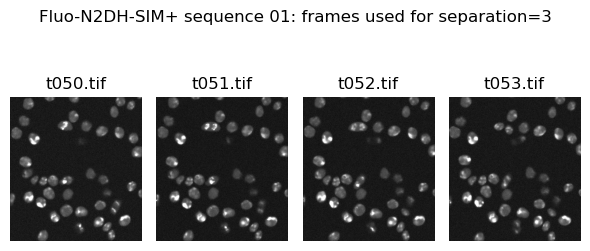

In [5]:
fig, axes = plt.subplots(1, len(preview_frames), figsize=(6, 3))
if len(preview_frames) == 1:
    axes = [axes]

for ax, frame, idx in zip(axes, preview_frames, preview_indices):
    ax.imshow(frame, cmap="gray")
    ax.set_title(frame_paths[idx].name)
    ax.axis("off")

plt.suptitle(
    f"{DATASET_NAME} sequence {SEQUENCE_ID}: frames used for separation={FRAME_SEPARATION}"
)
plt.tight_layout()
display(fig)
plt.close(fig)


## Single-pair flow

Run the selected method on the frame-separated pair and inspect color flow plus quiver.


In [6]:
def run_flow(label: str, method: str, params: dict, frame_a: np.ndarray, frame_b: np.ndarray) -> dict:
    print(f"Running {label} ({method})...")
    start = time.time()
    uv = estimate_flow(frame_a, frame_b, method=method, params=params or None)
    elapsed = time.time() - start
    magnitude = np.linalg.norm(uv, axis=2)
    result = {
        "label": label,
        "method": method,
        "params": params,
        "flow": uv,
        "time_s": elapsed,
        "mean_mag": float(np.mean(magnitude)),
        "median_mag": float(np.median(magnitude)),
        "p95_mag": float(np.percentile(magnitude, 95)),
    }
    print(
        f"  time={elapsed:.2f}s, mean|flow|={result['mean_mag']:.3f}px, "
        f"p95|flow|={result['p95_mag']:.3f}px"
    )
    return result


single_result = run_flow(FLOW_LABEL, FLOW_METHOD, FLOW_PARAMS, im1, im2)

print(
    f"{'Label':<20} {'Time (s)':>10} {'Mean |flow|':>14} "
    f"{'Median |flow|':>16} {'P95 |flow|':>12}"
)
print("-" * 80)
print(
    f"{single_result['label']:<20} {single_result['time_s']:>10.2f} "
    f"{single_result['mean_mag']:>14.3f} {single_result['median_mag']:>16.3f} "
    f"{single_result['p95_mag']:>12.3f}"
)


Running SEA-RAFT (sea-raft)...
  time=3.59s, mean|flow|=6.168px, p95|flow|=12.804px
Label                  Time (s)    Mean |flow|    Median |flow|   P95 |flow|
--------------------------------------------------------------------------------
SEA-RAFT                   3.59          6.168            5.586       12.804


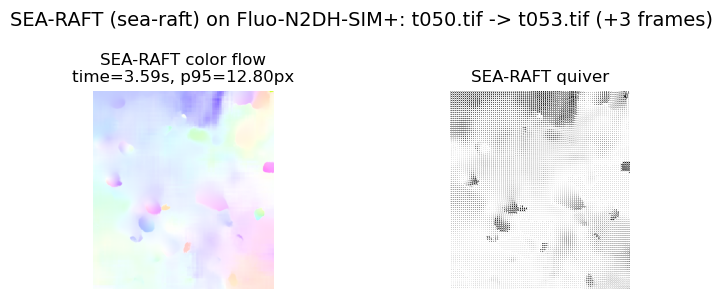

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
result = single_result
uv = result["flow"]

axes[0].imshow(flow_to_color(uv))
axes[0].set_title(
    f"{result['label']} color flow\n"
    f"time={result['time_s']:.2f}s, p95={result['p95_mag']:.2f}px"
)
axes[0].axis("off")

plot_flow(uv, style="quiver", ax=axes[1], step=QUIVER_STEP)
axes[1].set_title(f"{result['label']} quiver")

plt.suptitle(
    f"{result['label']} ({result['method']}) on {DATASET_NAME}: "
    f"{frame_paths[PAIR_INDEX].name} -> {frame_paths[PAIR_END_INDEX].name} "
    f"(+{FRAME_SEPARATION} frames)",
    fontsize=14,
)
plt.tight_layout()
display(fig)
plt.close(fig)


## Full-Sequence GIFs


In [10]:
def figure_to_pil(fig: plt.Figure) -> Image.Image:
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


def render_flow_movie_frame(frame: np.ndarray, uv: np.ndarray, title: str, quiver_step: int) -> Image.Image:
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))

    axes[0].imshow(frame, cmap="gray")
    axes[0].axis("off")

    axes[1].imshow(flow_to_color(uv))
    axes[1].set_aspect("equal")
    axes[1].axis("off")

    h, w = uv.shape[:2]
    y, x = np.mgrid[0:h:quiver_step, 0:w:quiver_step]
    axes[2].quiver(
        x,
        y,
        uv[::quiver_step, ::quiver_step, 0],
        uv[::quiver_step, ::quiver_step, 1],
        color="black",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003,
    )
    axes[2].set_ylim(h, 0)
    axes[2].set_xlim(0, w)
    axes[2].set_aspect("equal")
    axes[2].axis("off")

    plt.tight_layout()
    return figure_to_pil(fig)


def save_flow_gif(
    method_label: str,
    method: str,
    params: dict,
    frames: list[Path],
    output_path: Path,
    frame_separation: int = FRAME_SEPARATION,
    max_pairs: int | None = None,
    quiver_step: int = QUIVER_STEP,
    duration_ms: int = GIF_DURATION_MS,
) -> Path:
    if frame_separation < 1:
        raise ValueError("frame_separation must be at least 1")
    available_pairs = len(frames) - frame_separation
    pair_count = available_pairs if max_pairs is None else min(max_pairs, available_pairs)
    if pair_count <= 0:
        raise ValueError("Need at least one frame pair for GIF generation")

    rendered_frames = []
    for idx in range(pair_count):
        end_idx = idx + frame_separation
        frame_a = load_frame(frames[idx]).astype(float)
        frame_b = load_frame(frames[end_idx]).astype(float)
        print(
            f"{method_label}: pair {idx + 1}/{pair_count} "
            f"({frames[idx].name} -> {frames[end_idx].name}, +{frame_separation})"
        )
        uv = estimate_flow(frame_a, frame_b, method=method, params=params)
        rendered_frames.append(
            render_flow_movie_frame(
                frame_a,
                uv,
                f"{method_label}: {frames[idx].name} -> {frames[end_idx].name} (+{frame_separation})",
                quiver_step=quiver_step,
            )
        )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    rendered_frames[0].save(
        output_path,
        save_all=True,
        append_images=rendered_frames[1:],
        duration=duration_ms,
        loop=0,
        optimize=True,
    )
    print(f"Saved {output_path}")
    return output_path

SEA-RAFT: pair 1/10 (t000.tif -> t003.tif, +3)
SEA-RAFT: pair 2/10 (t001.tif -> t004.tif, +3)
SEA-RAFT: pair 3/10 (t002.tif -> t005.tif, +3)
SEA-RAFT: pair 4/10 (t003.tif -> t006.tif, +3)
SEA-RAFT: pair 5/10 (t004.tif -> t007.tif, +3)
SEA-RAFT: pair 6/10 (t005.tif -> t008.tif, +3)
SEA-RAFT: pair 7/10 (t006.tif -> t009.tif, +3)
SEA-RAFT: pair 8/10 (t007.tif -> t010.tif, +3)
SEA-RAFT: pair 9/10 (t008.tif -> t011.tif, +3)
SEA-RAFT: pair 10/10 (t009.tif -> t012.tif, +3)
Saved /Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/notebooks/outputs/cell_migration_demo/Fluo-N2DH-SIM+_01_sep3_sea_raft.gif


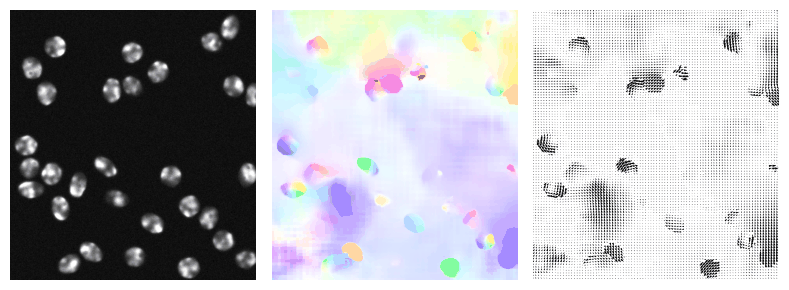

PosixPath('/Users/jordanshivers/Box Sync/NewLab/optical_flow/flow_code_python/notebooks/outputs/cell_migration_demo/Fluo-N2DH-SIM+_01_sep3_sea_raft.gif')

In [11]:
method_slug = FLOW_METHOD.replace("+", "_").replace("-", "_")
flow_gif_path = save_flow_gif(
    method_label=FLOW_LABEL,
    method=FLOW_METHOD,
    params=FLOW_PARAMS,
    frames=frame_paths,
    output_path=(
        OUTPUT_DIR
        / f"{DATASET_NAME}_{SEQUENCE_ID}_sep{FRAME_SEPARATION}_{method_slug}.gif"
    ),
    frame_separation=FRAME_SEPARATION,
    max_pairs=FULL_SEQUENCE_MAX_PAIRS,
    quiver_step=QUIVER_STEP,
    duration_ms=GIF_DURATION_MS,
)

gif_path = flow_gif_path
display(IPythonImage(filename=str(flow_gif_path)))
flow_gif_path
